# Pitcher WAR Predictions for 2026
Loads the best saved model (MVT or CNN) from `results/pitcher_model/` and generates
2026 WAR predictions using each pitcher's stats through the 2025 season.

In [1]:
RESULTS_DIR   = './results/pitcher_model/'
DATA_PATH     = './data/pitching_stats.csv'
PRED_SEASON   = 2025   # most-recent season used as the last lookback window
PRED_YEAR     = 2026   # the year we are forecasting
DEVICE        = 'mps'  # 'mps' for Apple Silicon, 'cpu' for fallback
MIN_QUAL_IP   = 50     # minimum IP in 2025 to include a pitcher
OUTPUT_CSV    = f'./results/pitcher_model/predictions_{PRED_YEAR}.csv'

In [2]:
import os
import json
import pickle

import numpy as np
import pandas as pd
import torch
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

from src.mvt_pitcher_model import MVTPitcherModel, MVTPitcherPredictionDataSet
from src.cnn_pitcher_model import CNNPitcherModel, CNNPitcherPredictionDataset

device = torch.device(DEVICE if DEVICE == 'mps' and torch.backends.mps.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: mps


## 1. Load metadata & determine model type

In [3]:
meta_path = os.path.join(RESULTS_DIR, 'metadata.json')
with open(meta_path) as f:
    metadata = json.load(f)

model_type   = metadata['model_type']          # 'MVT' or 'CNN'
hyperparams  = metadata['hyperparameters']
saved_metrics = metadata['metrics']

print(f'Model type : {model_type}')
print(f'Saved MSE  : {saved_metrics["mse"]:.4f}')
print(f'Saved MAE  : {saved_metrics["mae"]:.4f}')
print(f'Saved R²   : {saved_metrics["r2"]:.4f}')
print(f'Hyperparams: {hyperparams}')

Model type : MVT
Saved MSE  : 1.2176
Saved MAE  : 0.8552
Saved R²   : 0.4260
Hyperparams: {'d_model': 32, 'nhead': 2, 'num_layers': 1, 'dim_feedforward': 256, 'dropout': 0.24693217840034312, 'head_hidden1': 256, 'head_hidden2': 128, 'lr': 0.0001188685307280212, 'feature_weight': 0.15284466708653988, 'batch_size': 16}


## 2. Load pitching data

In [4]:
# Feature sets used during training — must match exactly
MVT_FEATURES = [
    'G', 'GS', 'IP', 'TBF', 'HR', 'BB', 'SO', 'GB', 'GB%', 'FB', 'FB%',
    'LD', 'Pitches', 'CSW%', 'K%', 'BB%', 'FIP',
]
CNN_FEATURES = [
    'Age', 'ERA', 'G', 'GS', 'IP', 'TBF', 'HR', 'BB', 'IBB', 'HBP', 'SO',
    'GB', 'GB%', 'FB', 'FB%', 'LD', 'LD%', 'IFFB', 'Pitches', 'BABIP', 'WHIP',
    'FIP', 'xFIP', 'SIERA', 'CStr%', 'CSW%', 'Barrels', 'Barrel%', 'HardHit', 'HardHit%',
]

features = MVT_FEATURES if model_type == 'MVT' else CNN_FEATURES

need_download = True
if os.path.exists(DATA_PATH):
    data = pd.read_csv(DATA_PATH)
    if 'IP' in data.columns:
        need_download = False
        print(f'Loaded {DATA_PATH}: {len(data)} rows')

if need_download:
    print('Downloading pitching stats via pybaseball…')
    from pybaseball import pitching_stats
    data = pitching_stats(start_season=2015, end_season=2025, qual=10)
    data.to_csv(DATA_PATH, index=False)
    print(f'Saved {len(data)} rows to {DATA_PATH}')

# Keep only seasons up to PRED_SEASON
data = data[data['Season'] <= PRED_SEASON].copy()
print(f'Seasons available: {sorted(data["Season"].unique())}')
print(f'Pitchers in {PRED_SEASON}: {len(data[data["Season"] == PRED_SEASON])}')

Loaded ./data/pitching_stats.csv: 6850 rows
Seasons available: [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Pitchers in 2025: 657


## 3. Rebuild model architecture & load weights

In [5]:
weights_path = os.path.join(RESULTS_DIR, 'best_model.pt')

if model_type == 'MVT':
    nlookbacks = hyperparams.get('seq_len', 5)  # MVT was trained with seq_len=5
    model = MVTPitcherModel(
        input_dim       = len(features),
        num_features    = len(features),
        d_model         = hyperparams['d_model'],
        nhead           = hyperparams['nhead'],
        num_layers      = hyperparams['num_layers'],
        dim_feedforward = hyperparams['dim_feedforward'],
        dropout         = hyperparams['dropout'],
        seq_len         = 5,
        head_hidden1    = hyperparams['head_hidden1'],
        head_hidden2    = hyperparams['head_hidden2'],
    )
    nlookbacks = 5

else:  # CNN
    nlookbacks = hyperparams['nlookbacks']
    model = CNNPitcherModel(
        input_channels = len(features),
        seq_length     = nlookbacks,
        conv1_out      = hyperparams['conv1_out'],
        conv1_kernel   = hyperparams['conv1_kernel'],
        conv2_out      = hyperparams['conv2_out'],
        conv2_kernel   = 1,  # always 1; pool collapses spatial dim
        dropout        = hyperparams['dropout'],
        fc1_hidden     = hyperparams['fc1_hidden'],
    )

model.load_state_dict(torch.load(weights_path, map_location='cpu'))
model = model.to(device)
model.eval()
print(f'{model_type} model loaded from {weights_path}')
print(f'nlookbacks = {nlookbacks}, features = {len(features)}')

MVT model loaded from ./results/pitcher_model/best_model.pt
nlookbacks = 5, features = 17


## 4. Load scaler

In [6]:
scaler_path = os.path.join(RESULTS_DIR, 'scaler.pkl')
with open(scaler_path, 'rb') as f:
    scaler = pickle.load(f)
print(f'Scaler loaded: {type(scaler).__name__}')

# MVT also stores per-feature normalisation stats for WAR denormalisation
if model_type == 'MVT':
    war_mean = metadata['war_mean']
    war_std  = metadata['war_std']
    print(f'WAR normalisation — mean: {war_mean:.4f}, std: {war_std:.4f}')

Scaler loaded: StandardScaler
WAR normalisation — mean: 1.3077, std: 1.3699


## 5. Build prediction sequences

In [7]:
if model_type == 'MVT':
    pred_ds = MVTPitcherPredictionDataSet(
        data       = data,
        pred_season= PRED_SEASON,
        features   = features,
        nlookbacks = nlookbacks,
    )
    pred_sequences = pred_ds.pred_sequences  # tensor (N, seq_len, num_features)
    pred_meta      = pred_ds.pred_metadata   # DataFrame indexed by player_id
else:
    pred_ds = CNNPitcherPredictionDataset(
        data       = data,
        pred_season= PRED_SEASON,
        features   = features,
        nlookbacks = nlookbacks,
    )
    pred_sequences = pred_ds.sequences  # tensor (N, seq_len, num_features)
    pred_meta      = pred_ds.metadata   # DataFrame indexed by player_id

print(f'Prediction sequences shape: {pred_sequences.shape}')
print(f'Players to predict: {len(pred_meta)}')

Prediction sequences shape: torch.Size([657, 5, 17])
Players to predict: 657


## 6. Scale sequences & run inference

In [8]:
X_np = pred_sequences.numpy()
N, seq_len, num_feat = X_np.shape

# Apply the same StandardScaler fitted during training
X_scaled = scaler.transform(X_np.reshape(-1, num_feat)).reshape(N, seq_len, num_feat)
X_tensor = torch.tensor(X_scaled, dtype=torch.float32).to(device)

war_preds_raw = []
batch_size = 64

with torch.no_grad():
    for start in range(0, N, batch_size):
        batch = X_tensor[start:start + batch_size]
        if model_type == 'MVT':
            _, war_pred = model(batch)
        else:
            war_pred = model(batch).squeeze(-1)
        war_preds_raw.extend(war_pred.cpu().numpy().tolist())

war_preds_raw = np.array(war_preds_raw)

# Denormalise for MVT (CNN targets were raw WAR)
if model_type == 'MVT':
    war_preds = war_preds_raw * war_std + war_mean
else:
    war_preds = war_preds_raw

print(f'Predictions generated: {len(war_preds)}')
print(f'  min={war_preds.min():.2f}, max={war_preds.max():.2f}, mean={war_preds.mean():.2f}')

Predictions generated: 657
  min=0.30, max=4.38, mean=1.09


## 7. Assemble results & join player names

In [9]:
results = pred_meta.copy().reset_index()
results.rename(columns={'player_id': 'IDfg'}, inplace=True)
results[f'predicted_WAR_{PRED_YEAR}'] = war_preds

# Pull the most-recent name / team / age from 2025 data
info_cols = ['IDfg', 'Name', 'Team', 'Age', 'IP']
available_info = [c for c in info_cols if c in data.columns]
info_2025 = (
    data[data['Season'] == PRED_SEASON][available_info]
    .drop_duplicates('IDfg')
)
# Filter to pitchers who met the IP threshold in 2025
if 'IP' in info_2025.columns:
    info_2025 = info_2025[info_2025['IP'] >= MIN_QUAL_IP]

results = results.merge(info_2025, on='IDfg', how='left')
results = results.sort_values(f'predicted_WAR_{PRED_YEAR}', ascending=False).reset_index(drop=True)
results.insert(0, 'Rank', results.index + 1)

display_cols = ['Rank', 'Name', 'Team', 'Age', 'IP', f'predicted_WAR_{PRED_YEAR}']
display_cols = [c for c in display_cols if c in results.columns]
print(results[display_cols].head(30).to_string(index=False))

 Rank                  Name Team  Age    IP  predicted_WAR_2026
    1           Paul Skenes  PIT 23.0 187.2            4.375325
    2          Tarik Skubal  DET 28.0 195.1            4.359033
    3       Garrett Crochet  BOS 26.0 205.1            4.211442
    4    Cristopher Sanchez  PHI 28.0 202.0            4.179959
    5    Yoshinobu Yamamoto  LAD 26.0 173.2            3.946911
    6            Logan Webb  SFG 28.0 207.0            3.864913
    7             Bryan Woo  SEA 25.0 186.2            3.781934
    8          Hunter Brown  HOU 26.0 185.1            3.752497
    9            Chris Sale  ATL 36.0 125.2            3.713774
   10            Sonny Gray  STL 35.0 180.2            3.517615
   11           Cole Ragans  KCR 27.0  61.2            3.475825
   12          Zack Wheeler  PHI 35.0 149.2            3.463588
   13         Logan Gilbert  SEA 28.0 131.0            3.298405
   14             Max Fried  NYY 31.0 195.1            3.280719
   15        Framber Valdez  HOU 31.0 19

## 8. Distribution of predicted WAR

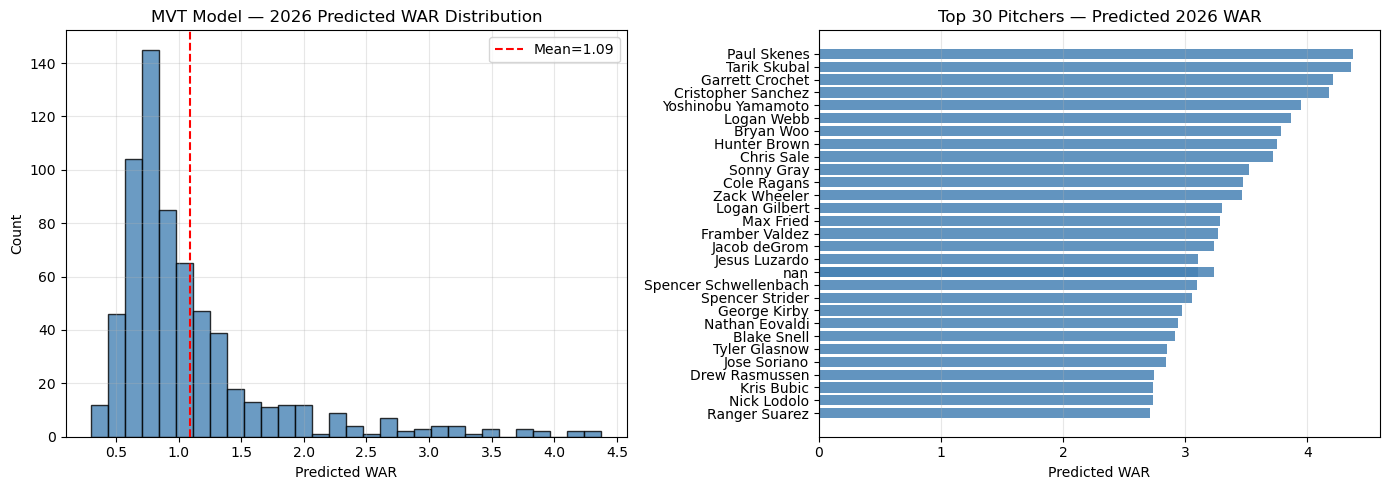

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(war_preds, bins=30, edgecolor='black', color='steelblue', alpha=0.8)
axes[0].axvline(war_preds.mean(), color='red', linestyle='--', label=f'Mean={war_preds.mean():.2f}')
axes[0].set_xlabel('Predicted WAR')
axes[0].set_ylabel('Count')
axes[0].set_title(f'{model_type} Model — {PRED_YEAR} Predicted WAR Distribution')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Top-30 bar chart — convert to plain lists to avoid pandas index issues
top30 = results.head(30)
label_col = 'Name' if 'Name' in top30.columns else 'IDfg'
labels = top30[label_col].astype(str).tolist()[::-1]
values = top30[f'predicted_WAR_{PRED_YEAR}'].tolist()[::-1]
axes[1].barh(labels, values, color='steelblue', alpha=0.85)
axes[1].set_xlabel('Predicted WAR')
axes[1].set_title(f'Top 30 Pitchers — Predicted {PRED_YEAR} WAR')
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

## 9. Save predictions to CSV

In [12]:
os.makedirs(os.path.dirname(OUTPUT_CSV), exist_ok=True)
results.to_csv(OUTPUT_CSV, index=False)
print(f'Saved {len(results)} predictions to {OUTPUT_CSV}')
results[display_cols].head(30)

Saved 657 predictions to ./results/pitcher_model/predictions_2026.csv


,Rank,Name,Team,Age,IP,predicted_WAR_2026
0,1,Paul Skenes,PIT,23.0,187.2,4.375325
1,2,Tarik Skubal,DET,28.0,195.1,4.359033
2,3,Garrett Crochet,BOS,26.0,205.1,4.211442
3,4,Cristopher Sanchez,PHI,28.0,202.0,4.179959
4,5,Yoshinobu Yamamoto,LAD,26.0,173.2,3.946911
5,6,Logan Webb,SFG,28.0,207.0,3.864913
6,7,Bryan Woo,SEA,25.0,186.2,3.781934
7,8,Hunter Brown,HOU,26.0,185.1,3.752497
8,9,Chris Sale,ATL,36.0,125.2,3.713774
9,10,Sonny Gray,STL,35.0,180.2,3.517615
